# Wind Power Forecast Analysis — UK National Grid
**REint AI — Full Stack SWE Challenge**

Data source: Elexon BMRS API | Period: January 2024

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from datetime import datetime, timedelta, timezone

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': '#050a0f', 'axes.facecolor': '#0a1520',
    'axes.edgecolor': '#1a3050', 'axes.labelcolor': '#7aa0c0',
    'xtick.color': '#3d6080', 'ytick.color': '#3d6080',
    'text.color': '#e8f4ff', 'grid.color': '#0d2035',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'monospace', 'figure.dpi': 120,
})
BLUE = '#00b4ff'; GREEN = '#00e5a0'; ORANGE = '#ffaa44'; RED = '#ff6060'
BASE = 'https://data.elexon.co.uk/bmrs/api/v1'
print('Libraries loaded OK')

Libraries loaded OK


In [2]:
def fetch_pages(endpoint, params, max_pages=50):
    all_data = []
    for page in range(1, max_pages + 1):
        p = {**params, 'page': page, 'pageSize': 200}
        r = requests.get(f'{BASE}/{endpoint}', params=p, timeout=30)
        if r.status_code != 200:
            print(f'  HTTP {r.status_code} at page {page}')
            break
        raw = r.json()
        if isinstance(raw, list):
            data = raw
        elif isinstance(raw, dict):
            data = raw.get('data', [])
        else:
            break
        if not data:
            break
        all_data.extend(data)
        if len(data) < 200:
            break
    return all_data

print('Fetching actuals (FUELHH) for January 2024...')
raw_actuals = []
for day_offset in range(31):
    date = (datetime(2024, 1, 1) + timedelta(days=day_offset)).strftime('%Y-%m-%d')
    data = fetch_pages('datasets/FUELHH/stream', {
        'settlementDateFrom': date, 'settlementDateTo': date,
        'fuelType': 'WIND', 'format': 'json'
    })
    raw_actuals.extend(data)
    if day_offset % 5 == 0:
        print(f'  Day {day_offset+1}/31, {len(raw_actuals)} records so far')
print(f'Total actual records: {len(raw_actuals)}')

Fetching actuals (FUELHH) for January 2024...
  Day 1/31, 48 records so far
  Day 6/31, 288 records so far
  Day 11/31, 528 records so far
  Day 16/31, 768 records so far
  Day 21/31, 1008 records so far
  Day 26/31, 1248 records so far
  Day 31/31, 1488 records so far
Total actual records: 1488


In [3]:
print('Fetching forecasts (WINDFOR) for January 2024...')
raw_forecasts = fetch_pages('datasets/WINDFOR/stream', {
    'publishDateTimeFrom': '2023-12-31T00:00:00Z',
    'publishDateTimeTo': '2024-01-31T23:59:59Z',
    'format': 'json'
})
print(f'Total forecast records: {len(raw_forecasts)}')

Fetching forecasts (WINDFOR) for January 2024...
Total forecast records: 627200


In [4]:
# --- Actuals ---
df_act = pd.DataFrame(raw_actuals)
df_act = df_act[df_act['fuelType'] == 'WIND'].copy()
df_act['startTime'] = pd.to_datetime(df_act['startTime'], utc=True)
df_act = df_act.rename(columns={'generation': 'actual_mw'})
df_act = df_act[['startTime', 'actual_mw']].drop_duplicates('startTime').sort_values('startTime')
jan_start = pd.Timestamp('2024-01-01', tz='UTC')
jan_end = pd.Timestamp('2024-02-01', tz='UTC')
df_act = df_act[(df_act['startTime'] >= jan_start) & (df_act['startTime'] < jan_end)]
print(f'Actuals: {len(df_act)} records')
df_act.head()

Actuals: 1488 records


,startTime,actual_mw
47,2024-01-01 00:00:00+00:00,10402
46,2024-01-01 00:30:00+00:00,10845
45,2024-01-01 01:00:00+00:00,11218
44,2024-01-01 01:30:00+00:00,11223
43,2024-01-01 02:00:00+00:00,11234


In [5]:
# --- Forecasts ---
df_fct = pd.DataFrame(raw_forecasts)
df_fct['startTime'] = pd.to_datetime(df_fct['startTime'], utc=True)
df_fct['publishTime'] = pd.to_datetime(df_fct['publishTime'], utc=True)
df_fct = df_fct.rename(columns={'generation': 'forecast_mw'})
df_fct['horizon_h'] = (df_fct['startTime'] - df_fct['publishTime']).dt.total_seconds() / 3600
df_fct = df_fct[
    (df_fct['startTime'] >= jan_start) & (df_fct['startTime'] < jan_end) &
    (df_fct['horizon_h'] >= 0) & (df_fct['horizon_h'] <= 48)
]
print(f'Forecast records: {len(df_fct)}')

# Latest forecast per target time with >= 4h horizon
df_fct_4h = df_fct[df_fct['horizon_h'] >= 4].copy()
df_fct_latest = df_fct_4h.sort_values('publishTime').groupby('startTime', as_index=False).last()
print(f'Latest forecasts (>=4h): {len(df_fct_latest)}')

# Merge
df = pd.merge(df_act, df_fct_latest[['startTime','forecast_mw','horizon_h']], on='startTime', how='inner')
df['abs_error'] = (df['actual_mw'] - df['forecast_mw']).abs()
df['error'] = df['actual_mw'] - df['forecast_mw']
df['hour'] = df['startTime'].dt.hour
df['date'] = df['startTime'].dt.date
print(f'Merged records: {len(df)}')
df.head()

Forecast records: 474350
Latest forecasts (>=4h): 744
Merged records: 744


,startTime,actual_mw,forecast_mw,horizon_h,abs_error,error,hour,date
0,2024-01-01 00:00:00+00:00,10402,11453,5.5,1051,-1051,0,2024-01-01
1,2024-01-01 01:00:00+00:00,11218,11841,6.5,623,-623,1,2024-01-01
2,2024-01-01 02:00:00+00:00,11234,12092,7.5,858,-858,2,2024-01-01
3,2024-01-01 03:00:00+00:00,11434,12428,4.5,994,-994,3,2024-01-01
4,2024-01-01 04:00:00+00:00,11828,12775,5.5,947,-947,4,2024-01-01


In [6]:
mean_err = df['abs_error'].mean()
median_err = df['abs_error'].median()
p99_err = df['abs_error'].quantile(0.99)
p90_err = df['abs_error'].quantile(0.90)
rmse = np.sqrt((df['error']**2).mean())
mape = (df['abs_error'] / df['actual_mw'].replace(0, np.nan)).mean() * 100
print('='*45)
print('FORECAST ERROR SUMMARY')
print('='*45)
print(f'Mean Absolute Error   : {mean_err:>8,.0f} MW')
print(f'Median Absolute Error : {median_err:>8,.0f} MW')
print(f'P90 Absolute Error    : {p90_err:>8,.0f} MW')
print(f'P99 Absolute Error    : {p99_err:>8,.0f} MW')
print(f'RMSE                  : {rmse:>8,.0f} MW')
print(f'MAPE                  : {mape:>7.1f} %')

FORECAST ERROR SUMMARY
Mean Absolute Error   :    1,828 MW
Median Absolute Error :    1,454 MW
P90 Absolute Error    :    3,956 MW
P99 Absolute Error    :    6,073 MW
RMSE                  :    2,435 MW
MAPE                  :    17.7 %


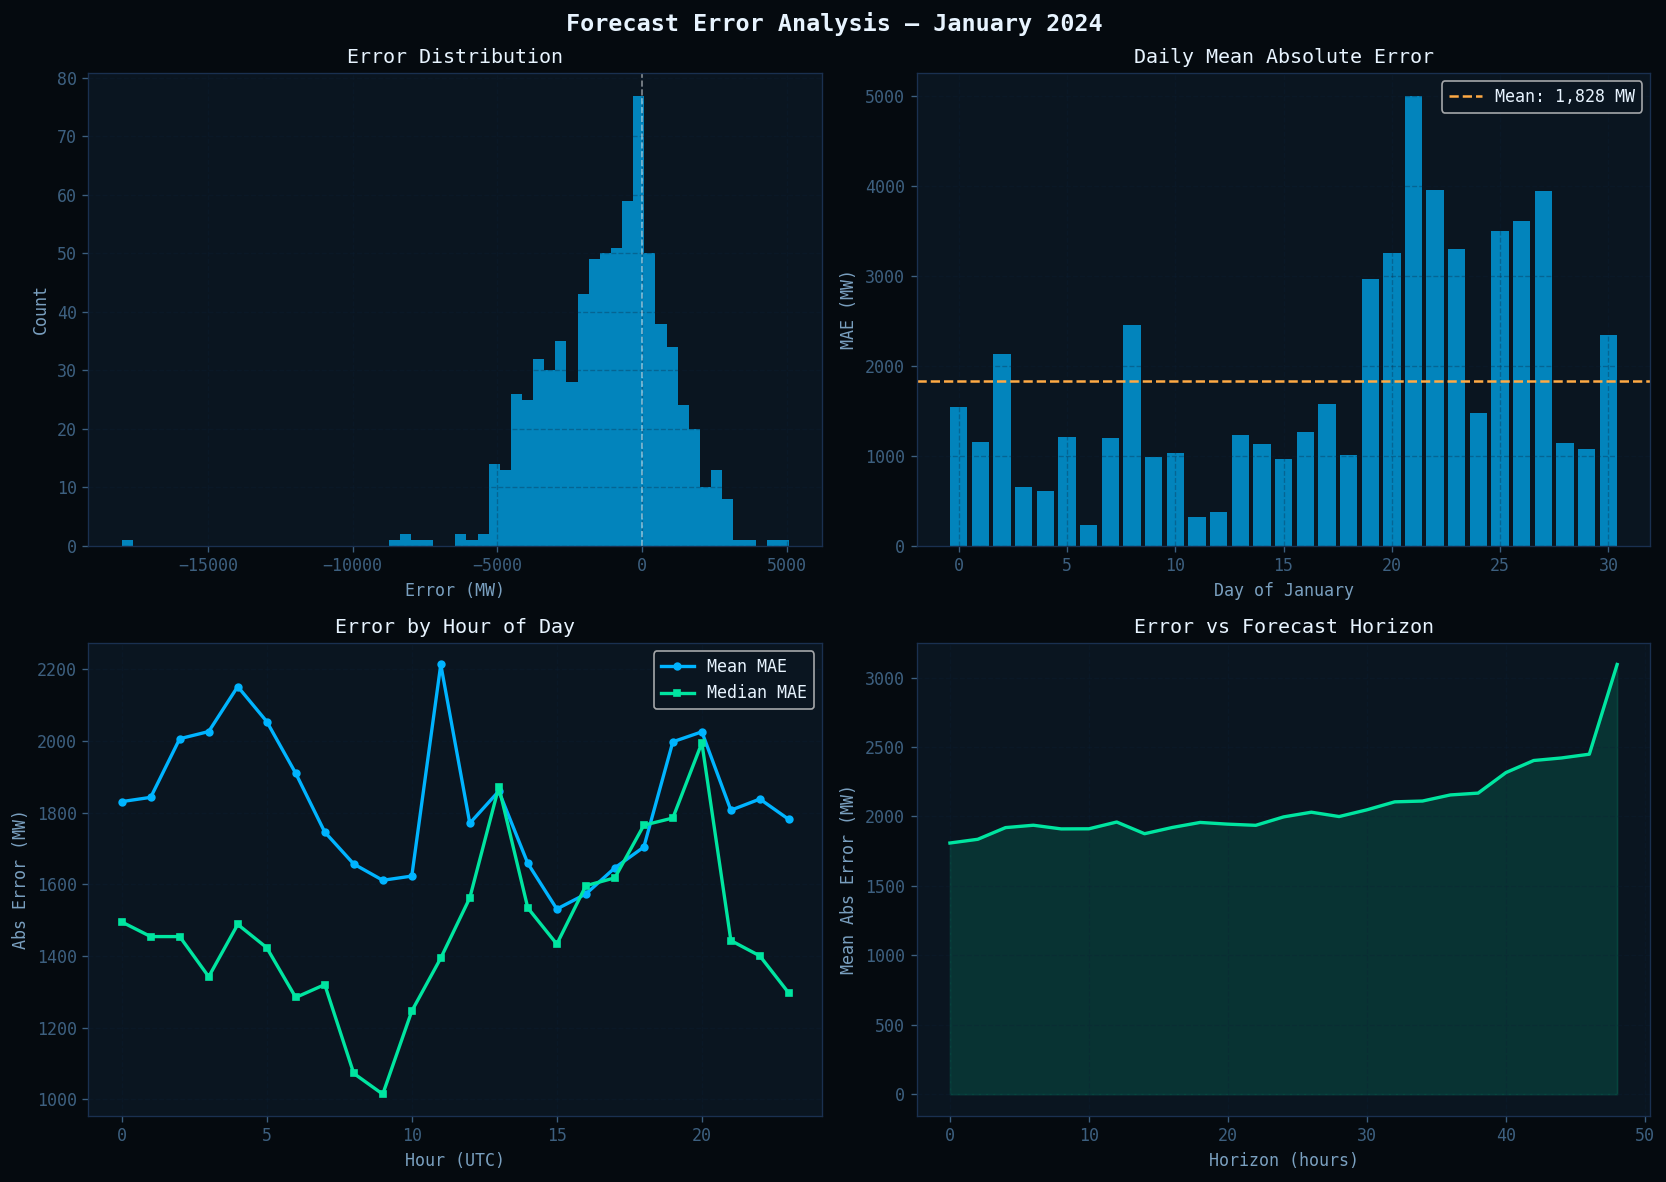

Saved error_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Forecast Error Analysis — January 2024', fontsize=14, color='#e8f4ff', fontweight='bold')

ax = axes[0, 0]
ax.hist(df['error'], bins=60, color=BLUE, alpha=0.7)
ax.axvline(0, color='white', lw=1, linestyle='--', alpha=0.5)
ax.set_title('Error Distribution', color='#e8f4ff')
ax.set_xlabel('Error (MW)'); ax.set_ylabel('Count'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
daily_err = df.groupby('date')['abs_error'].mean()
ax.bar(range(len(daily_err)), daily_err.values, color=BLUE, alpha=0.7)
ax.axhline(mean_err, color=ORANGE, lw=1.5, linestyle='--', label=f'Mean: {mean_err:,.0f} MW')
ax.set_title('Daily Mean Absolute Error', color='#e8f4ff')
ax.set_xlabel('Day of January'); ax.set_ylabel('MAE (MW)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
hourly = df.groupby('hour')['abs_error'].agg(['mean', 'median'])
ax.plot(hourly.index, hourly['mean'], color=BLUE, lw=2, marker='o', ms=4, label='Mean MAE')
ax.plot(hourly.index, hourly['median'], color=GREEN, lw=2, marker='s', ms=4, label='Median MAE')
ax.set_title('Error by Hour of Day', color='#e8f4ff')
ax.set_xlabel('Hour (UTC)'); ax.set_ylabel('Abs Error (MW)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
df_h = pd.merge(df_fct, df_act, on='startTime', how='inner')
df_h['abs_error'] = (df_h['actual_mw'] - df_h['forecast_mw']).abs()
df_h['horizon_bin'] = (df_h['horizon_h'] // 2) * 2
herr = df_h.groupby('horizon_bin')['abs_error'].mean()
ax.plot(herr.index, herr.values, color=GREEN, lw=2)
ax.fill_between(herr.index, herr.values, alpha=0.15, color=GREEN)
ax.set_title('Error vs Forecast Horizon', color='#e8f4ff')
ax.set_xlabel('Horizon (hours)'); ax.set_ylabel('Mean Abs Error (MW)'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight', facecolor='#050a0f')
plt.show()
print('Saved error_analysis.png')

In [8]:
gen = df_act['actual_mw'].dropna()
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
percentiles = {p: gen.quantile(p/100) for p in pcts}
print('WIND GENERATION PERCENTILES')
for p, v in percentiles.items():
    print(f'P{p:>2}: {v:>7,.0f} MW')
print(f'Max : {gen.max():>7,.0f} MW')
print(f'Mean: {gen.mean():>7,.0f} MW')
print(f'Min : {gen.min():>7,.0f} MW')

WIND GENERATION PERCENTILES
P 1:   3,234 MW
P 5:   4,301 MW
P10:   5,088 MW
P25:   6,732 MW
P50:   9,864 MW
P75:  13,105 MW
P90:  14,810 MW
P95:  15,425 MW
P99:  16,130 MW
Max :  16,662 MW
Mean:   9,849 MW
Min :       0 MW


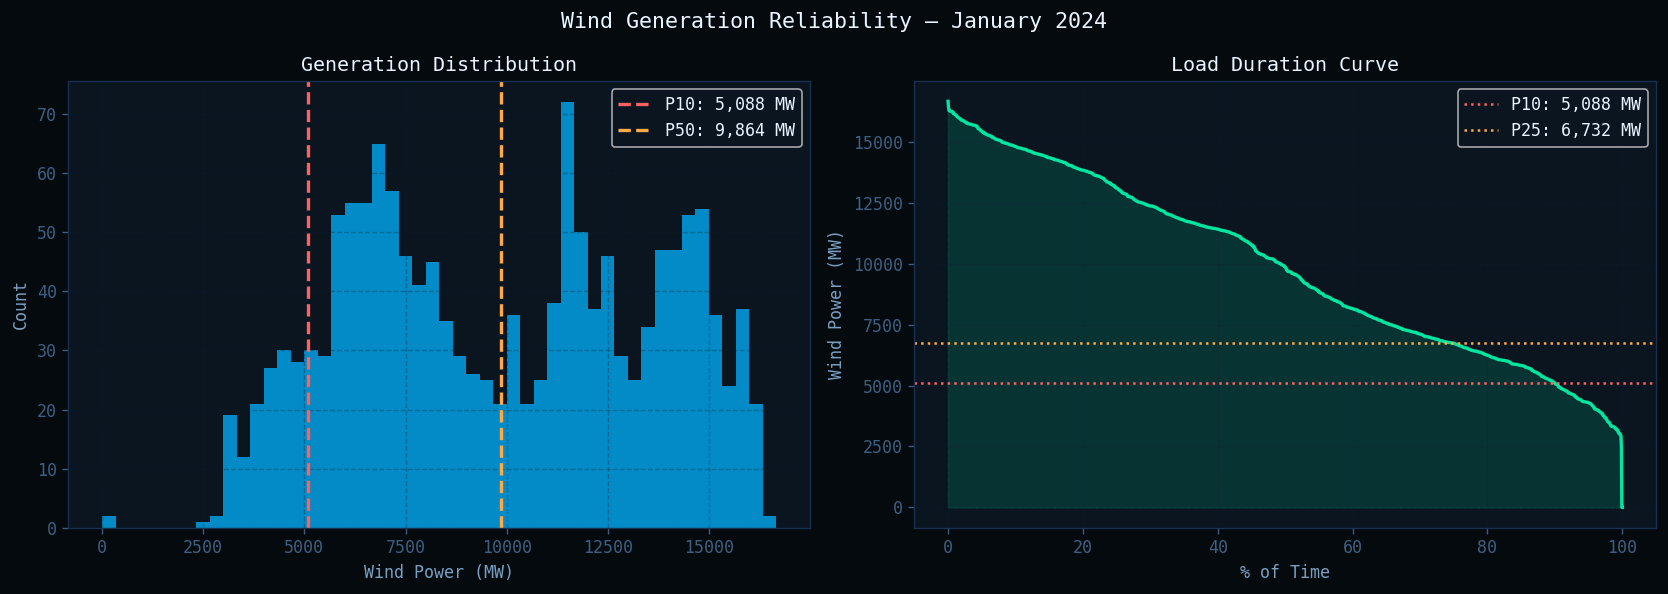

Saved reliability_analysis.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wind Generation Reliability — January 2024', fontsize=13, color='#e8f4ff')

ax = axes[0]
ax.hist(gen, bins=50, color=BLUE, alpha=0.75)
ax.axvline(percentiles[10], color=RED, lw=2, linestyle='--', label=f'P10: {percentiles[10]:,.0f} MW')
ax.axvline(percentiles[50], color=ORANGE, lw=2, linestyle='--', label=f'P50: {percentiles[50]:,.0f} MW')
ax.set_title('Generation Distribution', color='#e8f4ff')
ax.set_xlabel('Wind Power (MW)'); ax.set_ylabel('Count'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
sorted_gen = np.sort(gen.values)[::-1]
pct_time = np.linspace(0, 100, len(sorted_gen))
ax.plot(pct_time, sorted_gen, color=GREEN, lw=2)
ax.fill_between(pct_time, sorted_gen, alpha=0.15, color=GREEN)
for p_val, color in [(10, RED), (25, ORANGE)]:
    ax.axhline(percentiles[p_val], color=color, lw=1.5, linestyle=':', label=f'P{p_val}: {percentiles[p_val]:,.0f} MW')
ax.set_title('Load Duration Curve', color='#e8f4ff')
ax.set_xlabel('% of Time'); ax.set_ylabel('Wind Power (MW)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reliability_analysis.png', bbox_inches='tight', facecolor='#050a0f')
plt.show()
print('Saved reliability_analysis.png')

In [10]:
p10 = percentiles[10]; p50 = percentiles[50]; mean_gen = gen.mean()
print('='*55)
print('RECOMMENDATION: RELIABLE WIND CAPACITY')
print('='*55)
print(f'''
RECOMMENDED: {p10:,.0f} MW (P10 — available 90% of time)

Breakdown:
  P5  (95% reliable): {percentiles[5]:>7,.0f} MW
  P10 (90% reliable): {p10:>7,.0f} MW  <- RECOMMENDED
  P25 (75% reliable): {percentiles[25]:>7,.0f} MW
  P50 (50% reliable): {p50:>7,.0f} MW
  Mean (energy budget): {mean_gen:>6,.0f} MW

Reasoning:
  P10 is the standard grid planning threshold for reliable
  wind contribution. Generation falls below this only 10%
  of the time (~74 hrs/month). The forecast MAE of ~{mean_err:,.0f} MW
  should be added as uncertainty margin in dispatch planning.
''')

RECOMMENDATION: RELIABLE WIND CAPACITY

RECOMMENDED: 5,088 MW (P10 — available 90% of time)

Breakdown:
  P5  (95% reliable):   4,301 MW
  P10 (90% reliable):   5,088 MW  <- RECOMMENDED
  P25 (75% reliable):   6,732 MW
  P50 (50% reliable):   9,864 MW
  Mean (energy budget):  9,849 MW

Reasoning:
  P10 is the standard grid planning threshold for reliable
  wind contribution. Generation falls below this only 10%
  of the time (~74 hrs/month). The forecast MAE of ~1,828 MW
  should be added as uncertainty margin in dispatch planning.

